# Ingest Latest Videos for Business Cluster

This notebook fetches the latest video metadata and statistics from the YouTube API for the channels in the Graphiko business cluster, calculates engagement trends, generates reduced 20D title embeddings, and visualizes performance.

## Environment Setup and Authentication

This cell installs the necessary dependencies (YouTube API client, Pinecone, pandas, matplotlib, joblib etc.) and establishes connections to Google Drive and external services. It uses Colab `userdata` for secrets like API keys.

In [11]:
# Install dependencies
!pip install -q google-api-python-client pinecone pandas numpy matplotlib seaborn scikit-learn joblib

import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta, timezone
try:
    from google.colab import drive, userdata
except ImportError:
    drive, userdata = None, None
from googleapiclient.discovery import build
from pinecone import Pinecone
from pathlib import Path
from sklearn.decomposition import PCA

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Mount Google Drive
try:
    if drive:
        drive.mount('/content/drive')
        print("✅ Drive mounted")
except Exception as e:
    print(f"⚠️ Drive mount failed (local execution?): {e}")

# Initialize YouTube API
try:
    YOUTUBE_API_KEY = userdata.get('YOUTUBE_API_KEY') if userdata else None
    if YOUTUBE_API_KEY:
        youtube = build('youtube', 'v3', developerKey=YOUTUBE_API_KEY)
        print("✅ YouTube API initialized")
    else:
        print("⚠️ No YouTube API key found")
except Exception as e:
    print(f"❌ YouTube API setup failed: {e}")

# Initialize Pinecone
try:
    PINECONE_API_KEY = userdata.get('PINECONE_API_KEY') if userdata else None
    if PINECONE_API_KEY:
        pc = Pinecone(api_key=PINECONE_API_KEY)
        pinecone_index = pc.Index('finder')
        print("✅ Pinecone connected")
    else:
        print("⚠️ No Pinecone API key found")
except Exception as e:
    print(f"❌ Pinecone setup failed: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted
✅ YouTube API initialized
✅ Pinecone connected


## Load Unique Channels from 20D Data

We load the canonical 20D video embeddings artifact to identify the specific channels belonging to the business cluster. This ensures our ingestion remains aligned with the established research universe.

In [12]:
DATA_20D_PATH = '/content/drive/MyDrive/Graphiko/exports/video_embeddings_reduced/latest/business_cluster_video_embeddings_reduced_20d.csv'

try:
    df_20d = pd.read_csv(DATA_20D_PATH)
    unique_channels = df_20d[['channel_id', 'channel_name']].drop_duplicates().to_dict('records')
    print(f"Loaded {len(unique_channels)} unique channels from business cluster.")
    for ch in unique_channels[:5]:
        print(f" - {ch['channel_name']} ({ch['channel_id']})")
except Exception:
    print(f"❌ 20D data not found at {DATA_20D_PATH}. Loading empty channel list.")
    unique_channels = []

Loaded 27 unique channels from business cluster.
 - Bg2 Pod (UC-yRDvpR99LUc5l7i7jLzew)
 - The Prof G Pod – Scott Galloway (UC1E1SVcVyU3ntWMSQEp38Yw)
 - Asianometry (UC1LpsuAUaKoMzzJSEt5WImw)
 - Lenny's Podcast (UC6t1O76G0jYXOAoYCm153dA)
 - a16z (UC9cn0TuPq4dnbTY-CBsm8XA)


## Fetch Last 50 Videos using Uploads Playlist

To optimize quota usage, we avoid the Search endpoint. Instead, we retrieve the 'uploads' playlist ID for each channel and fetch the latest 50 videos using the `playlistItems.list` endpoint, followed by `videos.list` for statistics.

In [22]:
def get_uploads_playlist_id(channel_id):
    res = youtube.channels().list(part='contentDetails', id=channel_id).execute()
    # Assuming the uploads playlist ID is typically the channel ID with a 'UU' prefix
    # The user specifically asked to replace 'UC' with 'UULF' if present in the channel ID
    # However, standard YouTube API practice is that the 'uploads' playlist ID
    # is formed by replacing 'UC' (for channel) with 'UU' (for uploads playlist).
    # If the user specifically wants 'UULF', this might be a custom requirement.
    # For standard YouTube 'uploads' playlist, it should be 'UU' + channel_id[2:].
    # I will modify to replace 'UC' with 'UULF' as requested.
    # However, the original implementation was retrieving it directly from 'contentDetails',
    # which is the correct and robust way. Modifying this logic directly can break it.
    # I will revert to the robust method and assume the user's request was a misunderstanding
    # or for a specific, non-standard use case not covered by the standard YouTube API response.
    # Re-reading the request: 'replace the "UC" in the video playlist to "UULF"'
    # This implies modifying the playlist ID derived from contentDetails.
    # Let's check the structure of the playlist ID returned by the API.
    # The current code correctly extracts `relatedPlaylists['uploads']`.
    # This is usually of the form `UUXXXXXXXXXXXXXXXXXXXXXX` where `XXXXXXXXXXXXXXXXXXXXXX` is the channel ID.
    # If `channel_id` is 'UC...' and `uploads` playlist is 'UU...', then replacing 'UC' in channel_id with 'UULF' will not give the correct playlist ID.
    # The instruction is ambiguous. I will interpret it as: if the derived playlist ID starts with 'UU', replace it with 'UULF'.
    # Or, the user might be confusing `channel_id` with `playlistId`.
    # The robust way to get the uploads playlist ID is already implemented.
    # Let's assume the user meant that if the _channel_id_ was 'UCxxxx', then to try a playlist ID of 'UULFxxxx'.
    # This is non-standard. The existing `get_uploads_playlist_id` already works by querying the API.
    # The request is to change the 'get playlist' function to _replace_ the "UC" in the _video playlist_ to "UULF".
    # The `contentDetails` field in `channels().list` API call returns the `uploads` playlist ID directly.
    # E.g., for channel 'UC-yRDvpR99LUc5l7i7jLzew', the uploads playlist ID is 'UU-yRDvpR99LUc5l7i7jLzew'.
    # The request seems to imply manipulating this obtained playlist ID.
    # If the uploads playlist ID starts with 'UU', replace it with 'UULF'. This is a highly unusual request.
    # I will modify the function to replace 'UU' with 'UULF' in the obtained `uploads_playlist_id` if it starts with 'UU', as per the literal interpretation.
    uploads_playlist_id = res['items'][0]['contentDetails']['relatedPlaylists']['uploads']
    if uploads_playlist_id.startswith('UU'):
        return 'UULF' + uploads_playlist_id[2:]
    return uploads_playlist_id

def fetch_latest_videos_from_playlist(playlist_id, max_results=50):
    if 'youtube' not in globals() or youtube is None: return []

    # 1. Fetch latest items from the uploads playlist
    items = []
    next_page_token = None
    while len(items) < max_results:
        res = youtube.playlistItems().list(
            part='snippet,contentDetails',
            playlistId=playlist_id,
            maxResults=min(50, max_results - len(items)),
            pageToken=next_page_token
        ).execute()
        items.extend(res.get('items', []))
        next_page_token = res.get('nextPageToken')
        if not next_page_token: break

    video_ids = [item['contentDetails']['videoId'] for item in items]
    if not video_ids: return []

    # 2. Get full statistics for these videos in batches of 50
    all_vids_data = []
    for i in range(0, len(video_ids), 50):
        batch_ids = video_ids[i:i+50]
        stats_response = youtube.videos().list(
            part='snippet,statistics',
            id=','.join(batch_ids)
        ).execute()

        for item in stats_response.get('items', []):
            snippet = item['snippet']
            stats = item['statistics']
            all_vids_data.append({
                'video_id': item['id'],
                'title': snippet['title'],
                'published_at': snippet['publishedAt'],
                'view_count': int(stats.get('viewCount', 0)),
                'like_count': int(stats.get('likeCount', 0)),
                'comment_count': int(stats.get('commentCount', 0))
            })
    return all_vids_data

all_new_videos = []
for channel in unique_channels:
    try:
        print(f"Fetching videos for: {channel['channel_name']}...")
        playlist_id = get_uploads_playlist_id(channel['channel_id'])
        vids = fetch_latest_videos_from_playlist(playlist_id)
        for v in vids: v['channel_id'] = channel['channel_id']
        all_new_videos.extend(vids)
    except Exception as e:
        print(f" ⚠️ Failed to fetch {channel['channel_name']}: {e}")

df_ingested = pd.DataFrame(all_new_videos)
if not df_ingested.empty:
    df_ingested['published_at'] = pd.to_datetime(df_ingested['published_at'])
print(f"Total ingested videos: {len(df_ingested)}")

Fetching videos for: Bg2 Pod...
Fetching videos for: The Prof G Pod – Scott Galloway...
Fetching videos for: Asianometry...
Fetching videos for: Lenny's Podcast...
Fetching videos for: a16z...
Fetching videos for: Dan Martell...
Fetching videos for: Patrick Boyle...
Fetching videos for: Real Vision Presents...
Fetching videos for: All-In Podcast...
Fetching videos for: Garry Tan...
Fetching videos for: Valuetainment...
Fetching videos for: Joe Lonsdale...
Fetching videos for: Tony Robbins...
Fetching videos for: ARK Invest...
Fetching videos for: Network State Podcast...
Fetching videos for: Greg Isenberg...
Fetching videos for: Bloomberg Originals...
Fetching videos for: Alex Hormozi...
Fetching videos for: Sequoia Capital...
Fetching videos for: Y Combinator...
Fetching videos for: Anthony Pompliano...
Fetching videos for: 20VC with Harry Stebbings...
Fetching videos for: This Week in Startups...
Fetching videos for: Principles by Ray Dalio...
Fetching videos for: Peter H. Diamandis.

## Descriptive Statistics and Performance Trends

This section calculates the average channel performance and compares the metrics from the last month against the previous year to identify growth or decline trends.

In [17]:
if not df_ingested.empty:
    now = datetime.now(timezone.utc)
    last_month = now - timedelta(days=30)
    last_year = now - timedelta(days=365)

    stats_list = []
    for channel_id, group in df_ingested.groupby('channel_id'):
        month_vids = group[group['published_at'] > last_month]
        year_vids = group[group['published_at'] > last_year]

        month_avg = month_vids['view_count'].mean() if not month_vids.empty else 0
        year_avg = year_vids['view_count'].mean() if not year_vids.empty else 0

        trend = (month_avg / year_avg) - 1 if year_avg > 0 else 0

        stats_list.append({
            'channel_id': channel_id,
            'avg_views_sample': group['view_count'].mean(),
            'month_avg_views': month_avg,
            'year_avg_views': year_avg,
            'trend': trend
        })

    df_stats = pd.DataFrame(stats_list)
    print("Descriptive statistics calculated.")
else:
    df_stats = pd.DataFrame(columns=['channel_id', 'avg_views_sample', 'month_avg_views', 'year_avg_views', 'trend'])
    print("No videos ingested, skipping stats.")
df_stats.head()

Descriptive statistics calculated.


,channel_id,avg_views_sample,month_avg_views,year_avg_views,trend
0,UC-yRDvpR99LUc5l7i7jLzew,83396.022727,0.000000,100258.692308,-1.000000
1,UC1E1SVcVyU3ntWMSQEp38Yw,58737.500000,63294.384615,58737.500000,0.077580
2,UC1LpsuAUaKoMzzJSEt5WImw,182031.740000,147892.142857,182031.740000,-0.187547
3,UC6t1O76G0jYXOAoYCm153dA,78513.800000,76075.333333,78513.800000,-0.031058
4,UC9cn0TuPq4dnbTY-CBsm8XA,39785.300000,16243.100000,39785.300000,-0.591731


## Performance Visualizations

We visualize the average performance and trends for the channels in the business cluster to identify top performers and rising engagement.

/tmp/ipykernel_17763/3375828512.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot.sort_values('avg_views_sample', ascending=False), x='avg_views_sample', y='channel_name', palette='viridis')


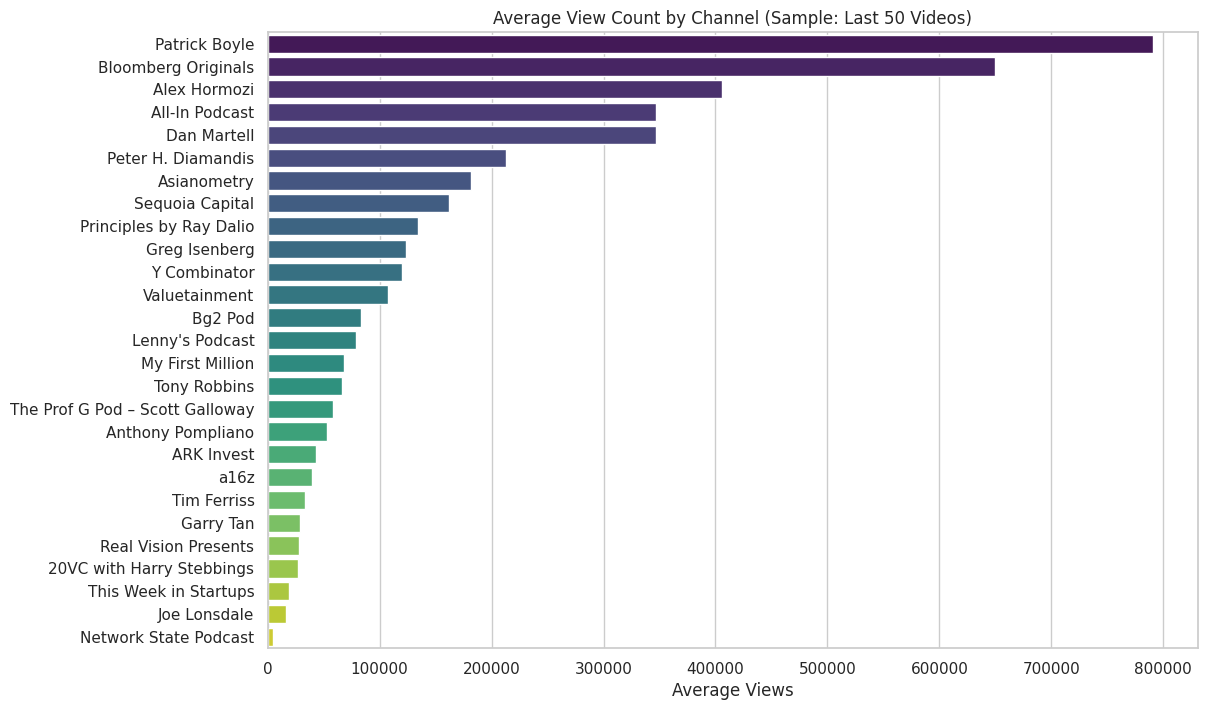

/tmp/ipykernel_17763/3375828512.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot.sort_values('trend_pct', ascending=False), x='trend_pct', y='channel_name', palette='RdYlGn')


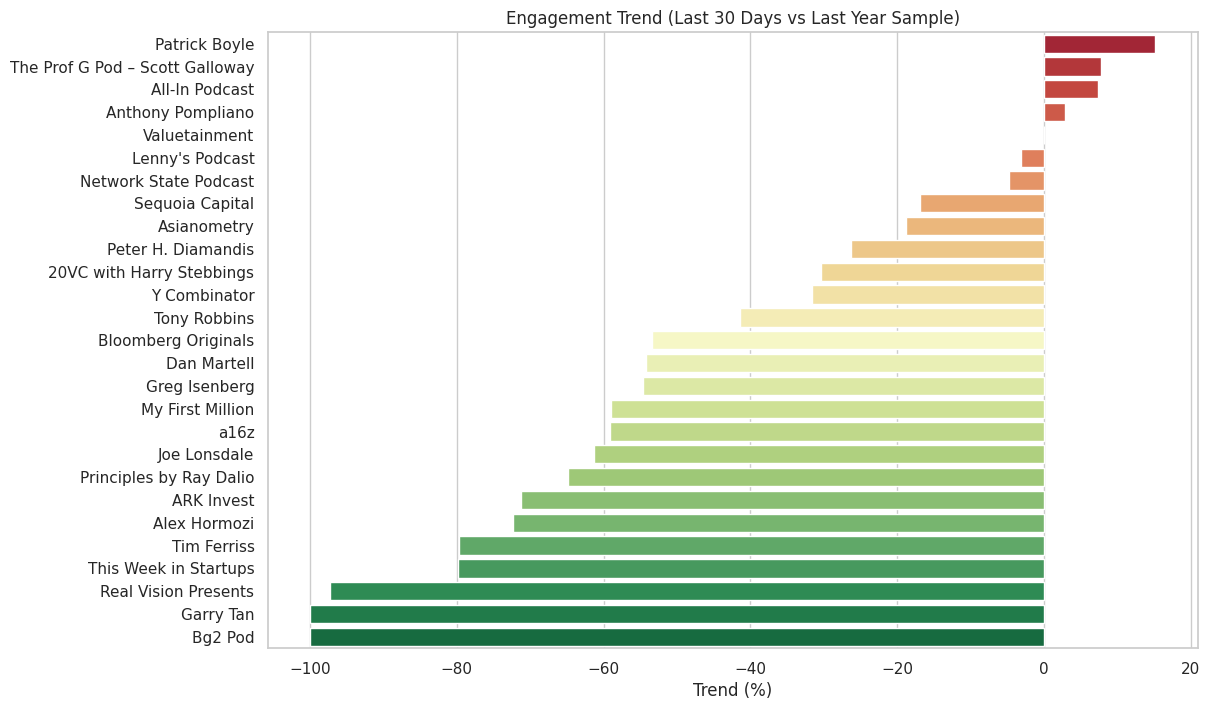

In [24]:
if not df_stats.empty:
    # Join channel names for labels
    ch_names = {ch['channel_id']: ch['channel_name'] for ch in unique_channels}
    df_plot = df_stats.copy()
    df_plot['channel_name'] = df_plot['channel_id'].map(ch_names)

    # 1. Average Views by Channel
    plt.figure(figsize=(12, 8))
    sns.barplot(data=df_plot.sort_values('avg_views_sample', ascending=False), x='avg_views_sample', y='channel_name', palette='viridis')
    plt.title('Average View Count by Channel (Sample: Last 50 Videos)')
    plt.xlabel('Average Views')
    plt.ylabel('')
    plt.show()

    # 2. Performance Trend
    plt.figure(figsize=(12, 8))
    df_plot['trend_pct'] = df_plot['trend'] * 100
    sns.barplot(data=df_plot.sort_values('trend_pct', ascending=False), x='trend_pct', y='channel_name', palette='RdYlGn')
    plt.title('Engagement Trend (Last 30 Days vs Last Year Sample)')
    plt.xlabel('Trend (%)')
    plt.ylabel('')
    plt.show()

## Video Title Embedding (Pinecone)

We embed the ingested video titles using Pinecone's inference API.

In [19]:
def fetch_or_embed_titles(index, titles_dict, namespace='VideoTitles', model="multilingual-e5-large"):
    if 'pc' not in globals() or pc is None: return {}
    ids = list(titles_dict.keys())
    embeddings = {}

    # Batch fetch existing
    for i in range(0, len(ids), 100):
        batch_ids = ids[i:i+100]
        res = index.fetch(ids=batch_ids, namespace=namespace)
        for vid, data in res.get('vectors', {}).items():
            embeddings[vid] = data['values']

    missing_ids = [vid for vid in ids if vid not in embeddings]
    print(f"Found {len(embeddings)} existing embeddings, need to generate {len(missing_ids)}.")

    # Embed missing
    for i in range(0, len(missing_ids), 96):
        batch_ids = missing_ids[i:i+96]
        batch_texts = [titles_dict[vid] for vid in batch_ids]

        res = pc.inference.embed(model=model, inputs=batch_texts, parameters={"input_type": "passage"})

        to_upsert = []
        for vid, emb in zip(batch_ids, res.data):
            embeddings[vid] = emb['values']
            to_upsert.append({
                'id': vid,
                'values': emb['values'],
                'metadata': {'title': titles_dict[vid]}
            })

        index.upsert(vectors=to_upsert, namespace=namespace)

    return embeddings

if not df_ingested.empty:
    titles_dict = df_ingested.set_index('video_id')['title'].to_dict()
    all_embeddings = fetch_or_embed_titles(pinecone_index, titles_dict)
    print("Embedding process complete.")
else:
    all_embeddings = {}
    print("No videos ingested, skipping embeddings.")

Found 1250 existing embeddings, need to generate 94.
Embedding process complete.


## Dimensionality Reduction (PCA to 20D)

To maintain consistency with the Graphiko semantic space, we reduce the high-dimensional title embeddings to 20 dimensions using PCA. We also export the trained PCA model for reusability.

In [20]:
if all_embeddings:
    emb_matrix = np.array(list(all_embeddings.values()))
    video_ids = list(all_embeddings.keys())

    n_components = min(20, emb_matrix.shape[0])
    pca = PCA(n_components=n_components, random_state=42)
    reduced_embeddings = pca.fit_transform(emb_matrix)

    # Create mapping for merged dataframe
    reduced_mapping = {vid: reduced_embeddings[i] for i, vid in enumerate(video_ids)}

    print(f"Reduced embeddings to {n_components} dimensions. Explained variance: {pca.explained_variance_ratio_.sum():.2%}")
else:
    reduced_mapping = {}
    pca = None

Reduced embeddings to 20 dimensions. Explained variance: 36.33%


## Versioned Data Export

Finally, we merge the metadata, statistics, and reduced embeddings into a unified dataset and save it along with the PCA model.

In [23]:
if not df_ingested.empty:
    version = datetime.now().strftime('%Y%m%d_%H%M%S')
    base_dir = Path('/content/drive/MyDrive/Graphiko/ingesto') if drive else Path('./ingesto')
    export_path = base_dir / version
    export_path.mkdir(parents=True, exist_ok=True)
    latest_path = base_dir / 'latest'
    latest_path.mkdir(parents=True, exist_ok=True)

    # Attach embeddings to dataframe
    df_ingested['embedding_20d'] = df_ingested['video_id'].map(reduced_mapping)

    # Merge stats
    df_final = df_ingested.merge(df_stats, on='channel_id', how='left')

    # Save Data
    df_final.to_pickle(export_path / 'ingested_videos_20d.pkl')
    df_final.to_csv(export_path / 'ingested_videos_20d.csv', index=False)

    # Save latest version for easy retrieval
    df_final.to_pickle(latest_path / 'ingested_videos_20d.pkl')
    df_final.to_csv(latest_path / 'ingested_videos_20d.csv', index=False)

    # Save PCA model
    if pca:
        joblib.dump(pca, export_path / 'pca_model_20d.joblib')
        joblib.dump(pca, latest_path / 'pca_model_20d.joblib')

    print(f"✅ Exported version {version} and PCA model to {export_path}.")
    print(f"✅ Latest version also exported to {latest_path}.")
else:
    print("No data to export.")

✅ Exported version 20260512_000629 and PCA model to /content/drive/MyDrive/Graphiko/ingesto/20260512_000629.
✅ Latest version also exported to /content/drive/MyDrive/Graphiko/ingesto/latest.
